In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

plt.style.use('default')

def save_simple_tex(df, filename, caption, label):
    df_out = df.copy()
    
    def fmt(x):
        if isinstance(x, (float, np.floating)):
            if abs(x) < 1e-10: return "0.0000"
            if abs(x) < 0.001: return "{:.2e}".format(x)
            return "{:.4f}".format(x)
        return x
    
    df_out = df_out.applymap(fmt)

    new_cols = []
    for col in df_out.columns:
        c = str(col)
        c = c.replace("Manual", "Man").replace("Library", "Lib")
        c = c.replace("Prediction", "Pred").replace("Difference", "Diff")
        c = c.replace("Statystyka", "Stat").replace("Wartość", "Val")
        new_cols.append(c)
    df_out.columns = new_cols

    df_out.to_latex(
        filename, index=True, caption=caption, label=label,
        position="H", column_format="l" + "c"*len(df_out.columns), escape=False
    )
    print(f"[OK] Wygenerowano: {filename}")

data = pd.read_csv('tabela1_6.txt', sep=r'\s+', header=None, names=['idx', 'GPA', 'IQ', 'Gender', 'PH'])

n = len(data)
y = data['GPA']
x_iq = data['IQ']

In [2]:
y_mean = np.mean(y)
x_mean = np.mean(x_iq)

Sxy = np.sum((x_iq - x_mean) * (y - y_mean))
Sxx = np.sum((x_iq - x_mean) ** 2)
b1_man = Sxy / Sxx
b0_man = y_mean - b1_man * x_mean

y_pred_man = b0_man + b1_man * x_iq
SSTO = np.sum((y - y_mean) ** 2)       # Całkowita zmienność
SSE = np.sum((y - y_pred_man) ** 2)    # Zmienność niewyjaśniona
SSR = SSTO - SSE                       # Zmienność wyjaśniona

r2_man = SSR / SSTO

X_sm = sm.add_constant(x_iq)
model_iq = sm.OLS(y, X_sm).fit()
r2_lib = model_iq.rsquared

# Tabela Porównawcza R^2
df_r2 = pd.DataFrame({
    'Manual': [r2_man],
    'Library': [r2_lib],
    'Diff': [r2_man - r2_lib]
}, index=['R-squared'])

save_simple_tex(df_r2, 'zad2_r2.tex', 'Współczynnik determinacji (Manual vs Python)', 'tab:zad2_r2')

print(f"Równanie: GPA = {b0_man:.4f} + {b1_man:.4f} * IQ")

[OK] Wygenerowano: zad2_r2.tex
Równanie: GPA = -3.5571 + 0.1010 * IQ


/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_8918/3345737662.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_out = df_out.applymap(fmt)


In [3]:
# Test F
# Stopnie swobody
df_reg = 1         
df_err = n - 2      

MSR = SSR / df_reg
MSE = SSE / df_err

F_man = MSR / MSE
p_val_man = stats.f.sf(F_man, df_reg, df_err) # (1 - cdf)

F_lib = model_iq.fvalue
p_val_lib = model_iq.f_pvalue

df_f_test = pd.DataFrame({
    'Statystyka F': [F_man, F_lib, F_man - F_lib],
    'P-wartość': [p_val_man, p_val_lib, p_val_man - p_val_lib]
}, index=['Manual', 'Library', 'Diff']).T 

save_simple_tex(df_f_test, 'zad2_ftest.tex', 'Wyniki testu F (Manual vs Python)', 'tab:zad2_f')

[OK] Wygenerowano: zad2_ftest.tex


/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_8918/3345737662.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_out = df_out.applymap(fmt)


<>:28: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:28: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_8918/1110159906.py:28: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  save_simple_tex(df_pred_comp, 'zad2_pred.tex', '90\% Przedziały predykcyjne (Manual vs Lib)', 'tab:zad2_pred')
/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_8918/3345737662.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_out = df_out.applymap(fmt)


[OK] Wygenerowano: zad2_pred.tex
[OK] Wykres zapisany. Liczba obserwacji poza przedziałem: 6 (7.7%)


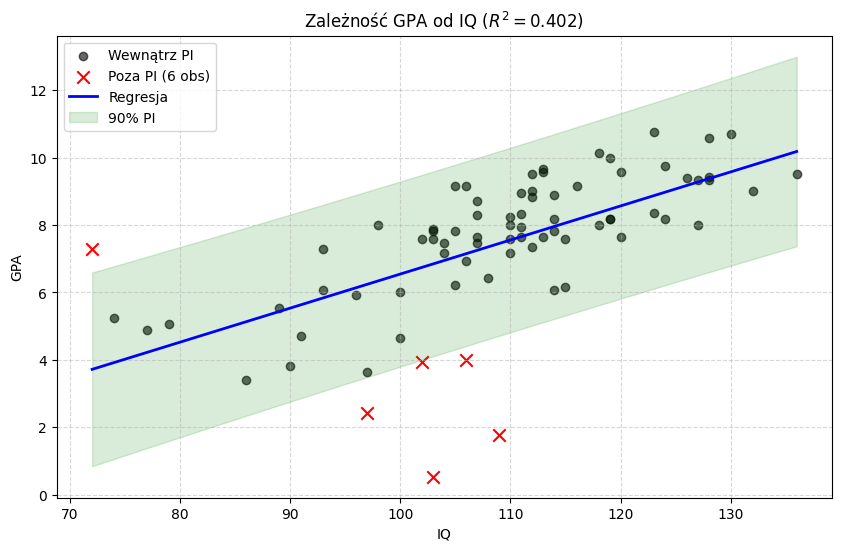

In [4]:
iq_targets = [75, 100, 140]
alpha = 0.10 # 90% przedział
t_crit = stats.t.ppf(1 - alpha/2, df=n-2)
mse_val = MSE # Z poprzedniej komórki

results_c = []
for val in iq_targets:
    pred = b0_man + b1_man * val
    # Wzór na błąd standardowy predykcji (Manual)
    se_pred = np.sqrt(mse_val * (1 + 1/n + (val - x_mean)**2 / Sxx))
    
    pi_low = pred - t_crit * se_pred
    pi_high = pred + t_crit * se_pred
    results_c.append([val, pred, pi_low, pi_high])

df_pred_man = pd.DataFrame(results_c, columns=['IQ', 'GPA', 'Man Low', 'Man High']).set_index('IQ')

pred_lib = model_iq.get_prediction(sm.add_constant(iq_targets)).summary_frame(alpha=0.10)
df_pred_comp = pd.DataFrame({
    'GPA Pred': df_pred_man['GPA'],
    'Man Low': df_pred_man['Man Low'],
    'Lib Low': pred_lib['obs_ci_lower'].values,
    'Man High': df_pred_man['Man High'],
    'Lib High': pred_lib['obs_ci_upper'].values
}, index=iq_targets)
df_pred_comp.index.name = 'IQ'

save_simple_tex(df_pred_comp, 'zad2_pred.tex', '90\% Przedziały predykcyjne (Manual vs Lib)', 'tab:zad2_pred')

full_pred = model_iq.get_prediction(X_sm).summary_frame(alpha=0.10)
outliers = (y < full_pred['obs_ci_lower']) | (y > full_pred['obs_ci_upper'])
n_out = outliers.sum()

plt.figure(figsize=(10, 6))

plt.scatter(x_iq[~outliers], y[~outliers], c='black', alpha=0.6, label='Wewnątrz PI')
plt.scatter(x_iq[outliers], y[outliers], c='red', marker='x', s=80, label=f'Poza PI ({n_out} obs)')

x_grid = np.linspace(x_iq.min(), x_iq.max(), 100)
grid_res = model_iq.get_prediction(sm.add_constant(x_grid)).summary_frame(alpha=0.10)

plt.plot(x_grid, grid_res['mean'], color='blue', linewidth=2, label='Regresja')
plt.fill_between(x_grid, grid_res['obs_ci_lower'], grid_res['obs_ci_upper'], color='green', alpha=0.15, label='90% PI')

plt.title(f'Zależność GPA od IQ ($R^2={r2_lib:.3f}$)')
plt.xlabel('IQ')
plt.ylabel('GPA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('zad2_wykres.png')
print(f"[OK] Wykres zapisany. Liczba obserwacji poza przedziałem: {n_out} ({n_out/n*100:.1f}%)")
plt.show()

[OK] Wygenerowano: zad2_compare.tex
[OK] Zapisano wykres PH.


/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_8918/2485225492.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Intercept': [model_iq.params[0], model_ph.params[0]],
/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_8918/2485225492.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Slope': [model_iq.params[1], model_ph.params[1]]
/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_8918/3345737662.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_out = df_out.applymap(fmt)


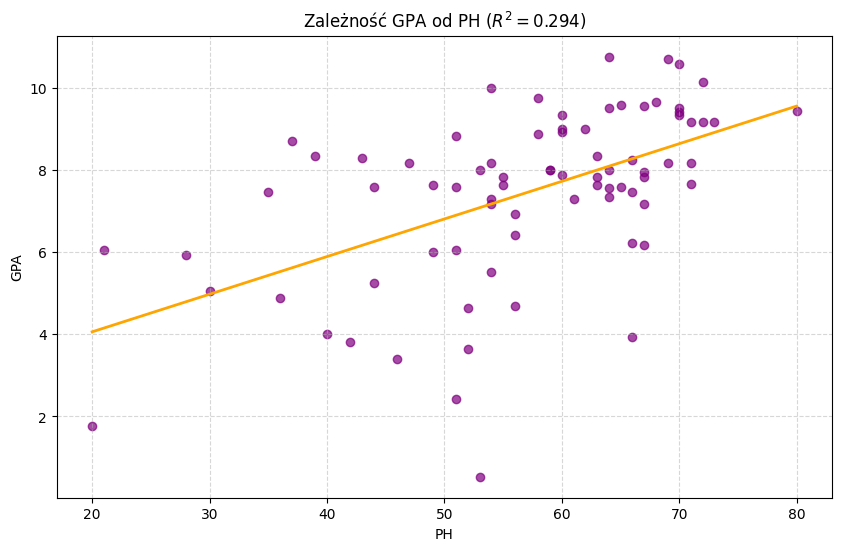

In [5]:
x_ph = data['PH']
model_ph = sm.OLS(y, sm.add_constant(x_ph)).fit()

df_compare = pd.DataFrame({
    'Predyktor': ['IQ', 'PH'],
    'R-squared': [model_iq.rsquared, model_ph.rsquared],
    'Intercept': [model_iq.params[0], model_ph.params[0]],
    'Slope': [model_iq.params[1], model_ph.params[1]]
}).set_index('Predyktor')

save_simple_tex(df_compare, 'zad2_compare.tex', 'Porównanie jakości modeli (IQ vs PH)', 'tab:zad2_comp')

plt.figure(figsize=(10, 6))
plt.scatter(x_ph, y, color='purple', alpha=0.7)
plt.plot(np.sort(x_ph), model_ph.predict(sm.add_constant(np.sort(x_ph))), color='orange', linewidth=2)
plt.title(f'Zależność GPA od PH ($R^2={model_ph.rsquared:.3f}$)')
plt.xlabel('PH')
plt.ylabel('GPA')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('zad2_wykres_ph.png')
print("[OK] Zapisano wykres PH.")
plt.show()